In [ ]:
import wfdb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
from scipy import signal as scipy_signal
from scipy.signal import butter, filtfilt, lfilter
from typing import Literal

## MIT-BIH Arrhythmia Database

### Arrhythmia Database contains 48 half-hour excerpts of two-channel ambulatory ECG recordings

In [2]:
records_folder = pathlib.Path('../data/physionet.org/files/mitdb/1.0.0')

In [ ]:
class Subject:
    def __init__(self, 
                 number, 
                 age, 
                 gender, 
                 meds, 
                 signal, 
                 annotations, 
                 filter_order=2, 
                 segmentation:Literal['fixed_window', 'r_peaks']='fixed_window', 
                 normalization:Literal['z_score', 'min_max']='z_score'
                ):
        
        self.number = number
        self.age = age
        self.gender = gender
        self.meds = meds
        
        # self.idx_mlii = sig_names.index('MLII') if 'MLII' in sig_names else 0
        # self.signal_mlii = signal[:, self.idx_mlii]
        
        self.raw_signal = signal
        signal_ch1 = self.preprocess_signal(signal[:,0], order=filter_order)
        signal_ch2 = self.preprocess_signal(signal[:,1], order=filter_order)
        self.signal = np.column_stack((signal_ch1, signal_ch2))
        
        self.arrhythmia_symbols = [
            # 'L', 'R', 'A', 'a', 'J', 'S', 'V', 'F', 'e', 'j', 'E', '/', 'f', 'Q', '?'
            'L', 'R', 'A', 'a', 'J', 'S', 'V', 'F', 'e', 'j', 'E', 'Q', '?'
        ]
        
        # Gera as janelas e rótulos
        if segmentation == 'r_peaks':
            self.windows_ch1 = self.get_r_peaks_windows(self.signal[:, 0], annotations)
            self.windows_ch2 = self.get_r_peaks_windows(self.signal[:, 1], annotations)
        if segmentation == 'fixed_window':
            self.windows_ch1 = self.get_signal_windows(self.signal[:, 0], annotations)
            self.windows_ch2 = self.get_signal_windows(self.signal[:, 1], annotations)
        else:
            raise ValueError

    
    def z_score(self, signal):
        media = np.mean(signal)
        desvio_padrao = np.std(signal)

        if desvio_padrao == 0:
            return (signal - media)
        
        return (signal - media) / desvio_padrao

    def minmax(self, sinal_janela):
        s_min = np.min(sinal_janela)
        s_max = np.max(sinal_janela)

        if s_max == s_min:
            return np.zeros_like(sinal_janela)
    
        return (sinal_janela - s_min) / (s_max - s_min)
    
    def butterworth_filter(self, signal, order, fs=360):
        nyquist = 0.5 * fs
        low, high = 0.5 / nyquist, 45.0 / nyquist

        b, a = butter(order, [low, high], btype='band')

        return filtfilt(b, a, signal)
    
    def preprocess_signal(self, raw_signal, order=2, fs=360, normalization_type='z_score'):

        filtered_signal = self.butterworth_filter(raw_signal, order, fs)
        if normalization_type == 'z_score':
            normalized_signal = self.z_score(filtered_signal)

        if normalization_type == 'min_max':
            normalized_signal = self.minmax(filtered_signal)
        return normalized_signal

    # REAL TIME
    def butterworth_lfilter(self, signal, order, fs=360):
        nyquist = 0.5 * fs
        low, high = 0.5 / nyquist, 45.0 / nyquist

        b, a = butter(order, [low, high], btype='band')

        return lfilter(b, a, signal)

    def get_signal_windows(self, single_channel_signal, annotations, fs=360, time=2, overlap=0.5):
        sig_buffer = int(fs * time) 
        step = int(sig_buffer * (1 - overlap))
        
        ann_samples = annotations.sample
        ann_symbols = annotations.symbol
        
        windows_list = []
        
        for i in range(0, len(single_channel_signal) - sig_buffer, step):
            start = i
            end = i + sig_buffer
            
            # Segmentação do sinal
            window_data = single_channel_signal[start:end]
            
            # Busca de anotações no intervalo da janela
            indices_na_janela = np.where((ann_samples >= start) & (ann_samples < end))[0]
            simbolos_na_janela = [ann_symbols[j] for j in indices_na_janela]
            
            # Lógica de rotulagem baseada na presença de arritmia
            label = 0
            if any(s in self.arrhythmia_symbols for s in simbolos_na_janela):
                label = 1
            
            windows_list.append({
                'signal': window_data,
                'label': label,
            })
            
        return windows_list
    
    def get_r_peaks_windows(self, single_channel_signal, annotations, fs=360):
        # Definição fisiológica (250ms antes do R, 450ms depois)
        # Total: 700ms de janela (252 amostras a 360Hz)
        before = int(0.25 * fs)
        after = int(0.45 * fs)

        ann_samples = annotations.sample
        ann_symbols = annotations.symbol
        pre_rr = 0.0
        windows_list = []

        for i, r_idx in enumerate(ann_samples):
            start = r_idx - before
            end = r_idx + after

            if start >= 0 and end < len(single_channel_signal):
                window_data = single_channel_signal[start:end]

                if i > 0:
                    pre_rr = (ann_samples[i] - ann_samples[i-1]) / fs

                indexes = np.where((ann_samples >= start) & (ann_samples < end))[0]
                symbols = [ann_symbols[j] for j in indexes]

                label = 0
                if any(s in self.arrhythmia_symbols for s in symbols):
                    label = 1

                windows_list.append({
                    'signal': window_data,
                    'label': label,
                    'pre_rr': pre_rr,
                })

        return windows_list

    def get_summary(self, channel):
        if channel == 1:
            windows = self.windows_ch1
        if channel == 2:
            windows = self.windows_ch2
        
        total = len(windows)
            
        positives = sum(w['label'] for w in windows)
        print(f"Paciente {self.number}: {total} janelas geradas.")
        print(f"Arritmias detectadas (Classe 1): {positives} | Normais (Classe 0): {total - positives}")
    
    def get_window_plot(self, channel:int, index:int, sig_size = 720):

        if channel == 1:
            window = self.windows_ch1[index]['signal']
        if channel == 2:
            window = self.windows_ch2[index]['signal']

        plt.figure(figsize=(10, 4))
        plt.plot(window[:sig_size], label=f'Channel {channel}', color='blue')

        plt.title(f"Subject channel {channel}")
        plt.xlabel("Sample #")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.legend()

        plt.show()
    
    def get_window_label(self, channel, index):

        if channel == 1:
            window = self.windows_ch1[index]
        if channel == 2:
            window = self.windows_ch2[index]
        
        return ("Normal" if window['label'] == 0 else "Arrythimic")

    def get_window_data(self, channel, index):
        if channel == 1:
            window = self.windows_ch1[index]
        if channel == 2:
            window = self.windows_ch2[index]
        
        return window['signal']

In [4]:
def get_available_pacients(path):
    ids = set()
    for subject in os.listdir(path):
        if os.path.isfile(os.path.join(path, subject)):
            id, _ = os.path.splitext(subject)
            if len(id) == 3:
                ids.add(id)
    return sorted(ids)

### Informações dos pacientes

In [5]:
def read_subject_info(subject):
    data_path = str(records_folder/subject)
    header = wfdb.rdheader(data_path)

    comments = header.comments[0].split(' ')
    age = int(comments[0])
    gender = comments[1]

    medicine = header.comments[1]

    return [subject, age, gender, medicine]

In [6]:
data = []
for pacient in get_available_pacients(records_folder):
    subject_data = read_subject_info(pacient)
    data.append(subject_data)

df = pd.DataFrame(data, columns=['ID', 'Idade', 'Gênero', 'Medicamentos'])
df.head()


,ID,Idade,Gênero,Medicamentos
0,100,69,M,"Aldomet, Inderal"
1,101,75,F,Diapres
2,102,84,F,Digoxin
3,103,-1,M,"Diapres, Xyloprim"
4,104,66,F,"Digoxin, Pronestyl"


### Leitura dos dados

In [7]:
def read_subject_signal(subject):
    data_path = str(records_folder/subject)
    record = wfdb.rdrecord(data_path)

    signal = record.p_signal
    fs = record.fs
    sig_name = record.sig_name

    return signal, fs, sig_name

In [8]:
def read_subject_annotation(subject):
    data_path = str(records_folder/subject)
    annotation =  wfdb.rdann(data_path, 'atr')

    return annotation

In [9]:
def read_subject_data(subject, verbose=False):
    
    signal, fs, sig_name = read_subject_signal(subject)
    annotation = read_subject_annotation(subject)
    if verbose:
        print(sig_name)
        print('Signal shape:', signal.shape)
        print('Signal frequency: ', fs)
        print('number of annotated beats: ', len(annotation.sample))

    return signal, fs, annotation

##### Data sample

In [10]:
available_pacients = get_available_pacients(records_folder)

subject = available_pacients[2]
signal, fs, annotation = read_subject_data(subject, verbose=True)

signal_channel_1 = signal[:, 0]
signal_channel_2 = signal[:, 1]

['V5', 'V2']
Signal shape: (650000, 2)
Signal frequency:  360
number of annotated beats:  2192


(650000,)
--- Estatísticas Pré-Normalização ---
Média: -0.0000
Desvio Padrão: 0.1802

--- Estatísticas Pós-Normalização ---
Média: 0.0000
Desvio Padrão: 1.0000


<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Igor Vasconcelos\AppData\Local\Temp\ipykernel_5840\1641642533.py:55: SyntaxWarning: invalid escape sequence '\s'
  axs[1].set_ylabel("Amplitude Normalizada (Unidades de $\sigma$)")


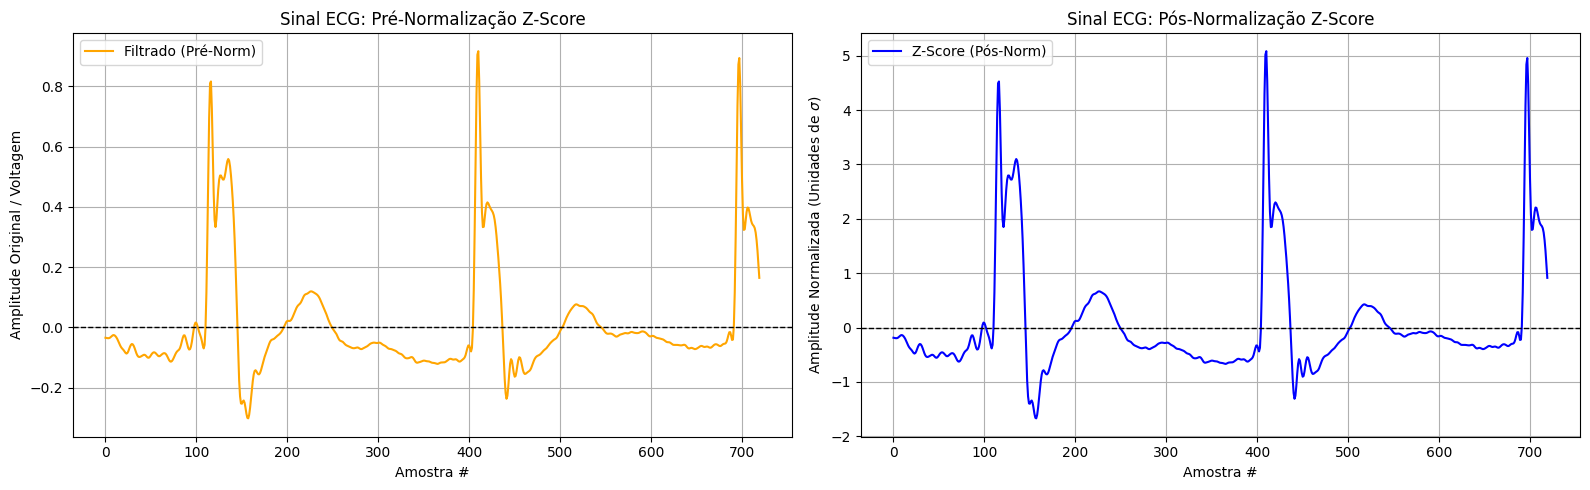

In [11]:
# DEBUG REMOVER ISSO DEPOIS
print(signal_channel_1.shape)

def butterworth_filter(signal, order, fs=360):
    nyquist = 0.5 * fs
    low, high = 0.5 / nyquist, 45.0 / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def z_score(signal):
    media = np.mean(signal)
    desvio_padrao = np.std(signal)
    
    # Printa as estatísticas pré-normalização para o console
    print(f"--- Estatísticas Pré-Normalização ---")
    print(f"Média: {media:.4f}")
    print(f"Desvio Padrão: {desvio_padrao:.4f}")
    
    if desvio_padrao == 0:
        return (signal - media)
    
    sinal_normalizado = (signal - media) / desvio_padrao
    
    # Printa as estatísticas pós-normalização para conferência
    print(f"\n--- Estatísticas Pós-Normalização ---")
    print(f"Média: {np.mean(sinal_normalizado):.4f}") # Deve ser ~0
    print(f"Desvio Padrão: {np.std(sinal_normalizado):.4f}") # Deve ser ~1
    
    return sinal_normalizado

# 1. Filtra o sinal (Pré-Normalização)
filtered = butterworth_filter(signal_channel_1, order=4)

# 2. Aplica o Z-Score (Pós-Normalização)
final = z_score(filtered)

# 3. Geração dos Gráficos Comparativos
# Criamos uma figura com dois subplots lado a lado
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

# Define o número de amostras para plotar (janela de ~2 segundos a 360Hz)
num_samples = 720

# --- Plot 1: Pré-Normalização (Sinal Apenas Filtrado) ---
axs[0].plot(filtered[:num_samples], color='orange', label='Filtrado (Pré-Norm)')
axs[0].set_title("Sinal ECG: Pré-Normalização Z-Score")
axs[0].set_ylabel("Amplitude Original / Voltagem")
axs[0].set_xlabel("Amostra #")
axs[0].grid(True)
axs[0].legend()

# --- Plot 2: Pós-Normalização (Sinal Z-Score) ---
axs[1].plot(final[:num_samples], color='blue', label='Z-Score (Pós-Norm)')
axs[1].set_title("Sinal ECG: Pós-Normalização Z-Score")
axs[1].set_ylabel("Amplitude Normalizada (Unidades de $\sigma$)")
axs[1].set_xlabel("Amostra #")
axs[1].grid(True)
axs[1].legend()

# Adiciona uma linha horizontal no zero para ambos os plots para referência da média
axs[0].axhline(0, color='black', linewidth=1, linestyle='--')
axs[1].axhline(0, color='black', linewidth=1, linestyle='--')

plt.tight_layout() # Ajusta o espaçamento para não sobrepor títulos/eixos
plt.show()

(720,)


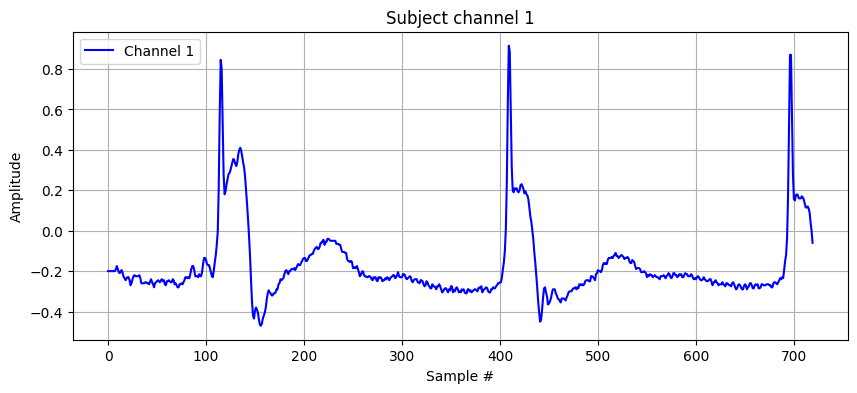

In [12]:
print(signal_channel_1[:720].shape)

plt.figure(figsize=(10, 4))
plt.plot(signal_channel_1[:720], label='Channel 1', color='blue')

plt.title("Subject channel 1")
plt.xlabel("Sample #")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.show()

(720,)


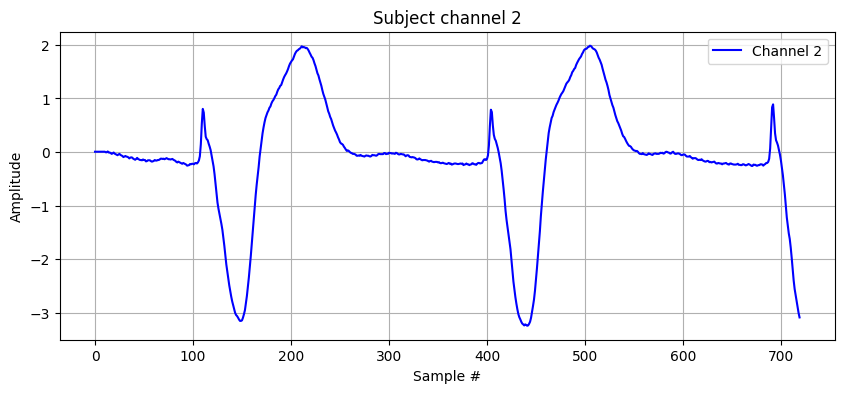

In [13]:
print(signal_channel_2[:720].shape)

plt.figure(figsize=(10, 4))
plt.plot(signal_channel_2[:720], label='Channel 2', color='blue')

plt.title("Subject channel 2")
plt.xlabel("Sample #")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.show()

In [14]:
print(annotation.sample[:10])
print(annotation.symbol[:10])

print(set(annotation.symbol))

[  68  136  410  697  989 1305 1614 1911 2201 2489]
['+', '/', '/', '/', '/', '/', '/', '/', '/', '/']
{'+', 'N', 'V', '/', 'f'}


#### Getting all the subjects data

In [ ]:
fixed_window_subjects : list[Subject] = []
for pacient in get_available_pacients(records_folder):
    subject_number, age, gender, meds = read_subject_info(pacient)
    signal, fs, notation = read_subject_data(pacient)

    current_subject = Subject(subject_number, age, gender, meds, signal, notation)
    fixed_window_subjects.append(current_subject)
    print('CANAL 1')
    current_subject.get_summary(1)
    print('CANAL 2')
    current_subject.get_summary(2)
    

CANAL 1
Paciente 100: 1804 janelas geradas.
Arritmias detectadas (Classe 1): 68 | Normais (Classe 0): 1736
CANAL 2
Paciente 100: 1804 janelas geradas.
Arritmias detectadas (Classe 1): 68 | Normais (Classe 0): 1736
CANAL 1
Paciente 101: 1804 janelas geradas.
Arritmias detectadas (Classe 1): 10 | Normais (Classe 0): 1794
CANAL 2
Paciente 101: 1804 janelas geradas.
Arritmias detectadas (Classe 1): 10 | Normais (Classe 0): 1794
CANAL 1
Paciente 102: 1804 janelas geradas.
Arritmias detectadas (Classe 1): 8 | Normais (Classe 0): 1796
CANAL 2
Paciente 102: 1804 janelas geradas.
Arritmias detectadas (Classe 1): 8 | Normais (Classe 0): 1796
CANAL 1
Paciente 103: 1804 janelas geradas.
Arritmias detectadas (Classe 1): 4 | Normais (Classe 0): 1800
CANAL 2
Paciente 103: 1804 janelas geradas.
Arritmias detectadas (Classe 1): 4 | Normais (Classe 0): 1800
CANAL 1
Paciente 104: 1804 janelas geradas.
Arritmias detectadas (Classe 1): 24 | Normais (Classe 0): 1780
CANAL 2
Paciente 104: 1804 janelas gerada

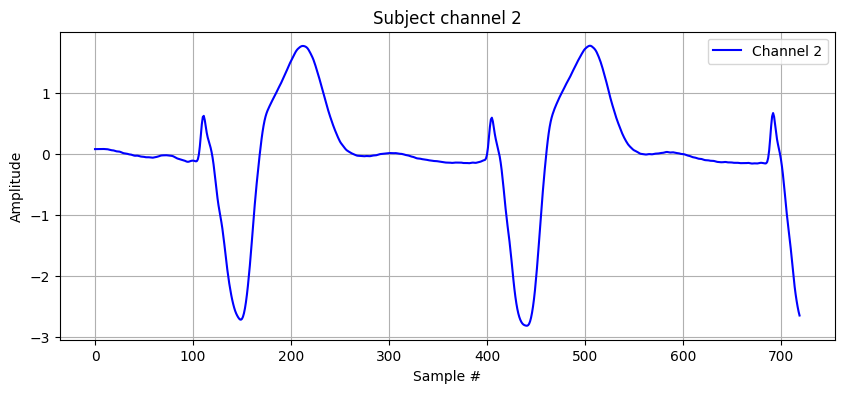

'Normal'

In [16]:
subjects[2].get_window_plot(2, 0)
subjects[2].get_window_label(2, 0)

### Distribuições

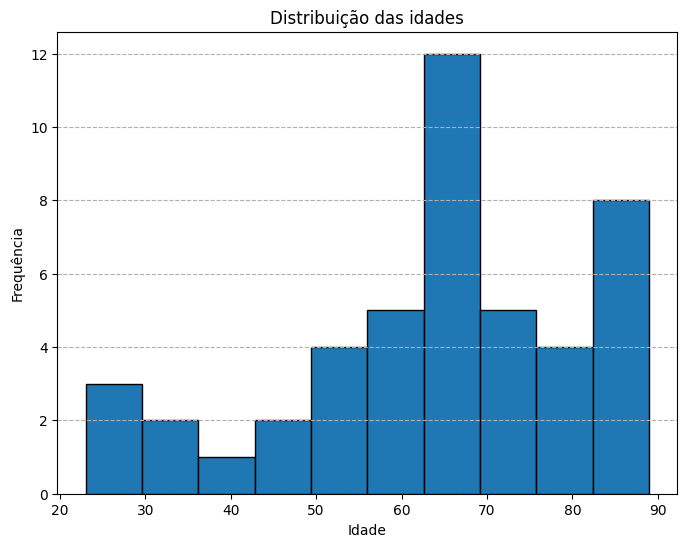

In [17]:
valid_ages = (df['Idade'][df['Idade'] != -1])

plt.figure(figsize=(8,6))
plt.hist(valid_ages, edgecolor="black")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.title("Distribuição das idades")
plt.grid(linestyle='--', axis='y')
plt.show()


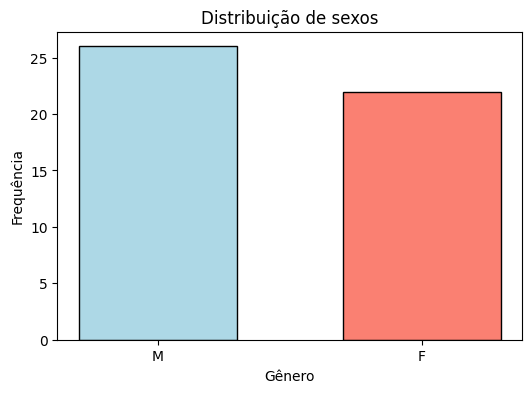

In [18]:
gender_count = df["Gênero"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    gender_count.index,
    gender_count.values,
    edgecolor='black',
    color=['lightblue', 'salmon'],
    width=0.6)
plt.xlabel('Gênero')
plt.ylabel('Frequência')
plt.title("Distribuição de sexos")
plt.show()


In [19]:
normal_times = []
arrythm_times = []
arrhythmia_symbols = ['L', 'R', 'A', 'a', 'J', 'S', 'V', 'F', 'e', 'j', 'E', 'Q', '?']


for sample, symbol in zip(annotation.sample, annotation.symbol):
    time = sample/fs
    tuple_member = (time, symbol)
    if symbol in arrhythmia_symbols:
        arrythm_times.append(tuple_member)
    else:
        normal_times.append(tuple_member)

2188 4


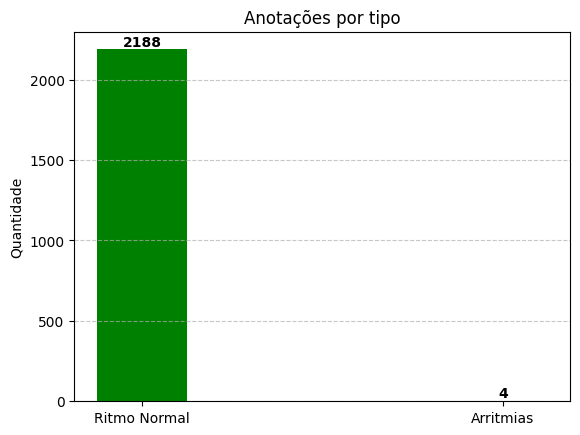

In [20]:
normal_count = len(normal_times)
arrythm_count = len(arrythm_times)

print(normal_count, arrythm_count)



# Rótulos e valores
labels = ['Ritmo Normal', 'Arritmias']
values = [normal_count, arrythm_count]

bars = plt.bar(labels, values, color=['green', 'red'], width=0.25)

plt.xlabel('')
plt.ylabel('Quantidade')
plt.title('Anotações por tipo')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.show()

In [21]:
normal_count/(normal_count+arrythm_count)*100

99.81751824817519

### Feature extraction

In [ ]:
def extract_average_energy(window, window_size=0):
    if window_size == 0:
        window_size = len(window['signal'])

### Subamostragem